# Medical imaging with MedGemma

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/tueimage/8dm60-multimodal-ai/blob/main/project/medical-imaging-starter.ipynb)

This starter workbook demoes three ways to work with a **medical generative vision-language model** and the Indiana University Chest X-ray dataset:

1. Generate a report for one chest X-ray and compare it with the reference report.
2. Extract frozen image features and explore their structure with t-SNE.
3. Adapt the language decoder with QLoRA and compare training and validation loss.


Each section introduces a question, implements one small experiment, and ends with some discussion questions. The sections are starting points for research questions, not complete experiments, nor an exhaustive set of research questions you can address as part of the project work. You can, but you are  not limited to use a MedGemme or a generative VLM in your project work, this is just one example of a model that is appropriate.

> **Important:** The first run downloads the complete dataset (about 14.2 GB) and the model weights. Make sure the runtime has at least 35 GB of free local disk space.


## Table of contents

1. [Overview and prerequisites](#1-overview-and-prerequisites)
2. [Settings](#2-settings)
3. [Download and prepare the dataset](#3-download-and-prepare-the-dataset)
4. [Load MedGemma](#4-load-medgemma)
5. [Generate and inspect a report](#5-generate-and-inspect-a-report)
6. [Explore image features](#6-explore-image-features)
7. [Fine-tune with QLoRA](#7-fine-tune-with-qlora)
8. [From demonstration to research project](#8-from-demonstration-to-research-project)


## 1. Overview and prerequisites

Use one of the following two compute options:

- **TU/e HPC:** For this course, we provide students access to one of our high performance computing (HPC) servers, which is equipped with NVIDIA 2080ti GPUs. More information will be given during the first BZ.
- **Google Colab:** choose **Runtime → Change runtime type → GPU**. Colab storage is temporary, so downloaded data is lost when the runtime is reset.

Run the installation cell once. **If it installs or changes packages, restart the Jupyter kernel or Colab runtime before continuing so the new packages take effect.** Then run the remaining cells section by section. Note that Section 7 performs GPU training and can take longer time to complete.

Before loading the model, visit the [MedGemma model page](https://huggingface.co/google/medgemma-4b-it) while signed in and accept the Health AI Developer Foundations terms. Also create a read token in your [Hugging Face settings](https://huggingface.co/settings/tokens). In Colab, you may store it as an `HF_TOKEN` secret and grant the notebook access; otherwise, a later cell opens the appropriate login interface.

The workbook uses the following libraries:

- **PyTorch** runs model inference and adapter training on the GPU.
- **torchvision** supplies image transforms used by the model processor.
- **Transformers** provides MedGemma, its processor, generation, and quantized loading.
- **Hugging Face Hub** authenticates access to the gated model and caches its files.
- **Accelerate** places the model on the GPU, without requiring CPU memory load first.
- **bitsandbytes** stores the frozen base model in 4-bit form so it fits in 11 GB.
- **PEFT** adds the small trainable LoRA adapters; together with a 4-bit base this is called QLoRA.
- **KaggleHub** downloads and caches the X-Ray dataset.
- **pandas** prepares report and projection metadata.
- **NumPy**, **Pillow**, **Matplotlib**, and **scikit-learn** support data handling, image loading, plots, PCA, and t-SNE.

The course environment installs the complete pinned stack. Colab keeps its preinstalled PyTorch, CUDA, and scientific Python stack and installs only the model-specific packages. This avoids replacing packages maintained as one compatible Colab runtime image. The environment cell reports the resulting versions for reproducibility.


In [12]:
from importlib.util import find_spec
import subprocess
import sys

print(f"Python {sys.version.split()[0]}")

# A direct dependencies are pinned to a specific versionso so all students
# work with the same model and preprocessing behavior.
model_requirements = [
    "transformers==4.57.6",
    "huggingface_hub==0.36.0",
    "accelerate==1.6.0",
    "bitsandbytes==0.49.2",
    "peft==0.15.2",
    "kagglehub==1.0.2",
    "num2words==0.5.14",
    "ipywidgets==8.1.8",
    "sentencepiece==0.2.1",
]

IN_COLAB = (
    find_spec("google") is not None
    and find_spec("google.colab") is not None
)

if IN_COLAB:
    # Keep Colab's matched PyTorch/CUDA and scientific Python packages.
    requirements = model_requirements
    print("Colab detected: keeping its preinstalled compute stack.")
else:
    requirements = [
        "torch==2.13.0",
        "torchvision==0.28.0",
        "pandas==3.0.3",
        "Pillow==12.3.0",
        "matplotlib==3.11.1",
        "scikit-learn==1.9.0",
        "numpy==2.5.1",
        *model_requirements,
    ]

# Install into the environment used by this notebook kernel.
subprocess.check_call(
    [
        sys.executable,
        "-m",
        "pip",
        "install",
        "--quiet",
        "--upgrade",
        "--disable-pip-version-check",
        *requirements,
    ]
)


Python 3.13.15
Colab detected: keeping its preinstalled compute stack.


0

In [18]:
%matplotlib inline

# Standard-library utilities handle paths, disk space, and reporting.
from importlib.metadata import version
from pathlib import Path
from shutil import disk_usage
import sys
import textwrap

# Scientific Python libraries handle data, images, plots, and projections.
import kagglehub
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from PIL import Image
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# Transformers supplies the multimodal processor, model, and quantization config.
from transformers import (
    AutoModelForImageTextToText,
    AutoProcessor,
    BitsAndBytesConfig,
)

if not torch.cuda.is_available():
    raise RuntimeError(
        "This workbook requires a CUDA-enabled PyTorch environment. "
        "Select the course GPU kernel, or choose a GPU runtime in Colab."
    )

# Print the library versions (for debugging purposes)
print(f"Python: {sys.version.split()[0]}")
for distribution in (
    "torch", "torchvision", "transformers", "huggingface_hub",
    "accelerate",
    "bitsandbytes", "peft", "kagglehub", "pandas", "Pillow",
    "matplotlib", "scikit-learn", "numpy", "num2words",
    "ipywidgets",
):
    print(f"{distribution}: {version(distribution)}")
print(f"GPU: {torch.cuda.get_device_name(0)}")


Python: 3.13.15
torch: 2.11.0+cu128
torchvision: 0.26.0+cu128
transformers: 4.57.6
huggingface_hub: 0.36.0
accelerate: 1.6.0
bitsandbytes: 0.49.2
peft: 0.15.2
kagglehub: 1.0.2
pandas: 2.2.3
Pillow: 11.3.0
matplotlib: 3.10.0
scikit-learn: 1.6.1
numpy: 2.1.3
num2words: 0.5.14
ipywidgets: 8.1.8
GPU: Tesla T4


## 2. Settings

The settings below are the main controls you may want to change:

- `PROMPT` is used for baseline generation, QLoRA training, validation, and the final comparison. It requests the short report format used in this exercise.
- `EXAMPLE_INDEX` selects one study ID from the reproducibly sorted table; counting starts at zero.
- `MAX_NEW_TOKENS` limits generated report length. Tokens are pieces of words, not an exact word count.
- `COMPUTE_DTYPE` selects the arithmetic precision used around the 4-bit weights. FP32 is slower but works consistently on the course RTX 2080 Ti and Colab GPUs; keeping it fixed also makes results easier to compare.
- `STUDIES_PER_CLASS` requests an equal number of studies for each report-derived feature label.
- `MAX_TRAINING_TOKENS` bounds the complete image-prompt-report sequence during training to control memory use.
- The default fine-tuning settings use 100 training and 20 validation studies for a relatively quick demonstration. Each block averages ten optimizer steps, and validation runs after every two blocks.

For a fuller experiment, set `TRAINING_STUDIES = 1000`, `VALIDATION_STUDIES = 100`, and `VALIDATE_EVERY_N_BLOCKS = 10`. Changing an early setting requires rerunning the cells that depend on it.


In [19]:
# General model and reproducibility settings.
SEED = 0
MODEL_ID = "google/medgemma-4b-it"
SYSTEM_PROMPT = "You are an expert radiologist."
PROMPT = (
    "Write a concise radiology report for this chest X-ray. "
    "Use Findings and Impression sections. Describe only findings "
    "supported by the image and state uncertainty when necessary."
)

MAX_NEW_TOKENS = 160
COMPUTE_DTYPE = torch.float32

# Report generation settings.
EXAMPLE_INDEX = 3

# Representation-exploration settings.
STUDIES_PER_CLASS = 100

# Quick QLoRA defaults; the preceding Markdown gives fuller settings.
TRAINING_STUDIES = 100
VALIDATION_STUDIES = 20
STUDIES_PER_BLOCK = 10
VALIDATE_EVERY_N_BLOCKS = 2
MAX_TRAINING_TOKENS = 640
FINETUNE_LEARNING_RATE = 2e-4


## 3. Download and prepare the dataset

The [Indiana University Chest X-ray dataset](https://openi.nlm.nih.gov/faq) contains chest X-rays paired with radiology reports. The KaggleHub call downloads the complete [Kaggle mirror](https://www.kaggle.com/datasets/raddar/chest-xrays-indiana-university) into its local cache. In Colab, the cache is stored on the runtime's fast local disk and disappears when the runtime is reset.

> One report can describe several images from the same study, often frontal and lateral views. This workbook keeps only one frontal image but compares it with the study-level report. A reference statement may therefore describe information that is not visible in the supplied image.

In [20]:
# Check if there is sufficient storage space for the dataset, model weights, and temporary files.
free_disk_gb = disk_usage(Path.home()).free / 2**30
print(f"Available disk space: {free_disk_gb:.1f} GB")
if free_disk_gb < 35:
    raise RuntimeError(
        "At least 35 GB of free disk space is required."
    )

# KaggleHub reuses its local cache after the first 14.2 GB download.
DATASET_ID = "raddar/chest-xrays-indiana-university"
dataset_root = Path(kagglehub.dataset_download(DATASET_ID))
print(f"Dataset directory: {dataset_root}")

Available disk space: 56.7 GB
Using Colab cache for faster access to the 'chest-xrays-indiana-university' dataset.
Dataset directory: /kaggle/input/chest-xrays-indiana-university


In [22]:
reports = pd.read_csv(dataset_root / "indiana_reports.csv")
projections = pd.read_csv(dataset_root / "indiana_projections.csv")
image_dir = dataset_root / "images" / "images_normalized"

# Replace missing report sections with empty text, strip leading and trailing whitespace.
for column in ("findings", "impression"):
    reports[column] = reports[column].fillna("").str.strip()


def first_of_projection(df, projection):
    """Deterministically select one image per study for the given projection."""
    return (
        df[df["projection"].str.lower().eq(projection)]
        .sort_values(["uid", "filename"])
        .drop_duplicates("uid")
    )


frontals = first_of_projection(projections, "frontal")
laterals = first_of_projection(projections, "lateral")

combined = (
    frontals[["uid", "filename"]]
    .rename(columns={"filename": "frontal_filename"})
    .merge(
        laterals[["uid", "filename"]].rename(columns={"filename": "lateral_filename"}),
        on="uid",
        how="inner",
        validate="one_to_one",
    )
)


def prepare(images, filename_columns):
    """Join reports with images, drop empty reports, attach absolute image paths."""
    studies = reports.merge(images, on="uid", validate="one_to_one")
    studies = (
        studies[studies["findings"].ne("") | studies["impression"].ne("")]
        .sort_values("uid")
        .reset_index(drop=True)
    )
    for filename_col, path_col in filename_columns.items():
        studies[path_col] = studies[filename_col].map(image_dir.joinpath)
    return studies


studies_f = prepare(frontals, {"filename": "image_path"})
studies_l = prepare(laterals, {"filename": "image_path"})
studies_c = prepare(
    combined,
    {
        "frontal_filename": "frontal_image_path",
        "lateral_filename": "lateral_image_path",
    },
)

print(f"Prepared {len(studies_f):,} frontal-image studies.")
print(f"Prepared {len(studies_l):,} lateral-image studies.")
print(f"Prepared {len(studies_c):,} combined-image studies.")

Prepared 3,666 frontal-image studies.
Prepared 3,536 lateral-image studies.
Prepared 3,376 combined-image studies.


In [6]:
def format_reference(row):
    """Combine findings and impression sections of a report."""
    sections = []
    if row["findings"]:
        sections.append(f"Findings\n{row['findings']}")
    if row["impression"]:
        sections.append(f"Impression\n{row['impression']}")
    return "\n\n".join(sections)


def load_xray(path):
    """Load a scan as RGB image (RGB format is expected by MedGemma)."""
    with Image.open(path) as opened_image:
        return opened_image.convert("RGB")


# Select the reproducible example used throughout the generation sections.
if not 0 <= EXAMPLE_INDEX < len(studies):
    raise IndexError(
        f"EXAMPLE_INDEX must be between 0 and {len(studies) - 1}."
    )

study = studies.iloc[EXAMPLE_INDEX]
image = load_xray(study["image_path"])
reference_report = format_reference(study)

print(f"Selected study {study['uid']} ({study['filename']}).")


Selected study 4 (4_IM-2050-2001.dcm.png).


## 4. Load MedGemma

[MedGemma 4B Instruct](https://huggingface.co/google/medgemma-4b-it) is a generative medical vision-language model based on Gemma 3. Its vision encoder was pretrained on several kinds of medical imagery, including chest X-rays. See Sellergren et al. (2025), [*MedGemma Technical Report*](https://arxiv.org/abs/2507.05201).

Gemma 3 converts each image to a fixed 896×896 encoder input. We retain that native resolution and for speed and simplicity we disable optional **pan-and-scan**, which adds additional local crops to the input.

To reduce GPU memory use, we load the model with its weights quantized to 4 bit NF4 format. The published MedGemma examples use BF16 computation, but the RTX 2080 Ti used in the course does not support BF16 natively, and the GPU provided by Colab may vary. On the RTX 2080 Ti, FP16 can become numerically unstable and cause the model to generate empty responses. We therefore use FP32 computation together with the quantized weights in both environments. This is slower but a lot more reliable. For reference, the numerical formats mentioned above are briefly summarized below.

| Format | Explanation |
|---|---|
| **NF4** | A 4 bit quantization format designed for normally distributed model weights that substantially reduces GPU memory use. |
| **FP16** | A 16 bit floating point format that is fast and memory efficient on many GPUs but can be numerically unstable. |
| **BF16** | A 16 bit floating point format with a wider numerical range than FP16, but it requires compatible GPU hardware for efficient native computation. |
| **FP32** | A 32 bit floating point format that uses more memory and computation but generally provides the greatest numerical stability. |

### Authorize the model download

MedGemma is a gated model, meaning that you must sign in to Hugging Face and accept the model’s terms before you can download its files. First accept its terms on the [model page](https://huggingface.co/google/medgemma-4b-it), using the same Hugging Face account that owns your read token. The next cell reuses an available token or opens the appropriate login interface for Jupyter or Colab.

In [7]:
from huggingface_hub import HfApi, hf_hub_download, login

# Reuse an existing token, including Colab's HF_TOKEN secret.
# An interactive prompt appears only when no token is available.
login(new_session=False)

# Verify the account and its access to the gated MedGemma repository.
hf_account = HfApi().whoami()["name"]
hf_hub_download(MODEL_ID, "config.json")

print(f"Authenticated with Hugging Face as {hf_account}.")


config.json: 0.00B [00:00, ?B/s]

Authenticated with Hugging Face as WesselNuijten.


In [8]:
# Load the processor that prepares both text and images for MedGemma.
processor = AutoProcessor.from_pretrained(MODEL_ID, use_fast=False)
# Disable creation of additional local image crops during preprocessing.
processor.image_processor.do_pan_and_scan = False

quantization_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_use_double_quant=True,
    bnb_4bit_compute_dtype=COMPUTE_DTYPE,
)
model = AutoModelForImageTextToText.from_pretrained(
    MODEL_ID,
    quantization_config=quantization_config,
    dtype=COMPUTE_DTYPE,
    attn_implementation="eager", # Use the standard but slower implementation for broad GPU compatibility.
    device_map={"": 0},
    low_cpu_mem_usage=True,
).eval()

print(f"MedGemma image size: {processor.image_processor.size}")
print(f"GPU memory after loading: {torch.cuda.memory_allocated() / 2**30:.1f} GB")


processor_config.json:   0%|          | 0.00/70.0 [00:00<?, ?B/s]

chat_template.jinja: 0.00B [00:00, ?B/s]

preprocessor_config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/4.69M [00:00<?, ?B/s]

...

model-00001-of-00002.safetensors:   0%|          | 0.00/4.96G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

/usr/local/lib/python3.13/dist-packages/bitsandbytes/backends/cuda/ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


generation_config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

MedGemma image size: {'height': 896, 'width': 896}
GPU memory after loading: 4.3 GB


## 5. Generate and inspect a report

MedGemma follows Gemma 3's chat format. A system message establishes the role, and the user message contains the actual image plus the editable prompt. The processor inserts visual tokens, resizes the image, and tokenizes the conversation. The generation is deterministic (`do_sample=False`) so prompt changes are easier to compare.


In [9]:
def make_messages(current_image, prompt, assistant_text=None):
    """Build one image-and-text conversation for MedGemma."""
    messages = [
        {
            "role": "system",
            "content": [{"type": "text", "text": SYSTEM_PROMPT}],
        },
        {
            "role": "user",
            "content": [
                {"type": "text", "text": prompt},
                {"type": "image", "image": current_image},
            ],
        },
    ]
    # During training, append the reference report as the target response.
    if assistant_text is not None:
        messages.append(
            {
                "role": "assistant",
                "content": [{"type": "text", "text": assistant_text}],
            }
        )
    return messages


def encode_messages(messages, add_generation_prompt, **tokenizer_kwargs):
    """Apply the model's chat template and create PyTorch tensors."""
    return processor.apply_chat_template(
        messages,
        add_generation_prompt=add_generation_prompt,
        tokenize=True,
        return_dict=True,
        return_tensors="pt",
        **tokenizer_kwargs,
    )


def move_batch_to_gpu(batch, device):
    """Move a processor batch to the GPU."""
    batch = {name: value.to(device) for name, value in batch.items()}
    batch["pixel_values"] = batch["pixel_values"].to(COMPUTE_DTYPE)
    return batch


def generate_report(current_model, current_image, prompt, max_new_tokens):
    """Generate a report and decode only tokens created by the model.

    ``generate`` returns the input prompt followed by the new response, so
    the prompt length is recorded and removed before decoding.
    """
    batch = encode_messages(
        make_messages(current_image, prompt),
        add_generation_prompt=True,
    )
    batch = move_batch_to_gpu(batch, current_model.device)
    input_length = batch["input_ids"].shape[1]

    with torch.inference_mode():
        output_ids = current_model.generate(
            **batch,
            do_sample=False,
            use_cache=True,
            max_new_tokens=max_new_tokens,
        )

    new_token_ids = output_ids[0, input_length:]
    return processor.decode(
        new_token_ids,
        skip_special_tokens=True,
        clean_up_tokenization_spaces=False,
    ).strip()


In [10]:
# Generate a deterministic baseline before any adapter training.
generated_report = generate_report(
    model, image, PROMPT, MAX_NEW_TOKENS
)
print(f"Prompt: {PROMPT}")

/usr/local/lib/python3.13/dist-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


Prompt: Write a concise radiology report for this lateral chest X-ray. Use Findings and Impression sections. Describe only findings supported by the image and state uncertainty when necessary.


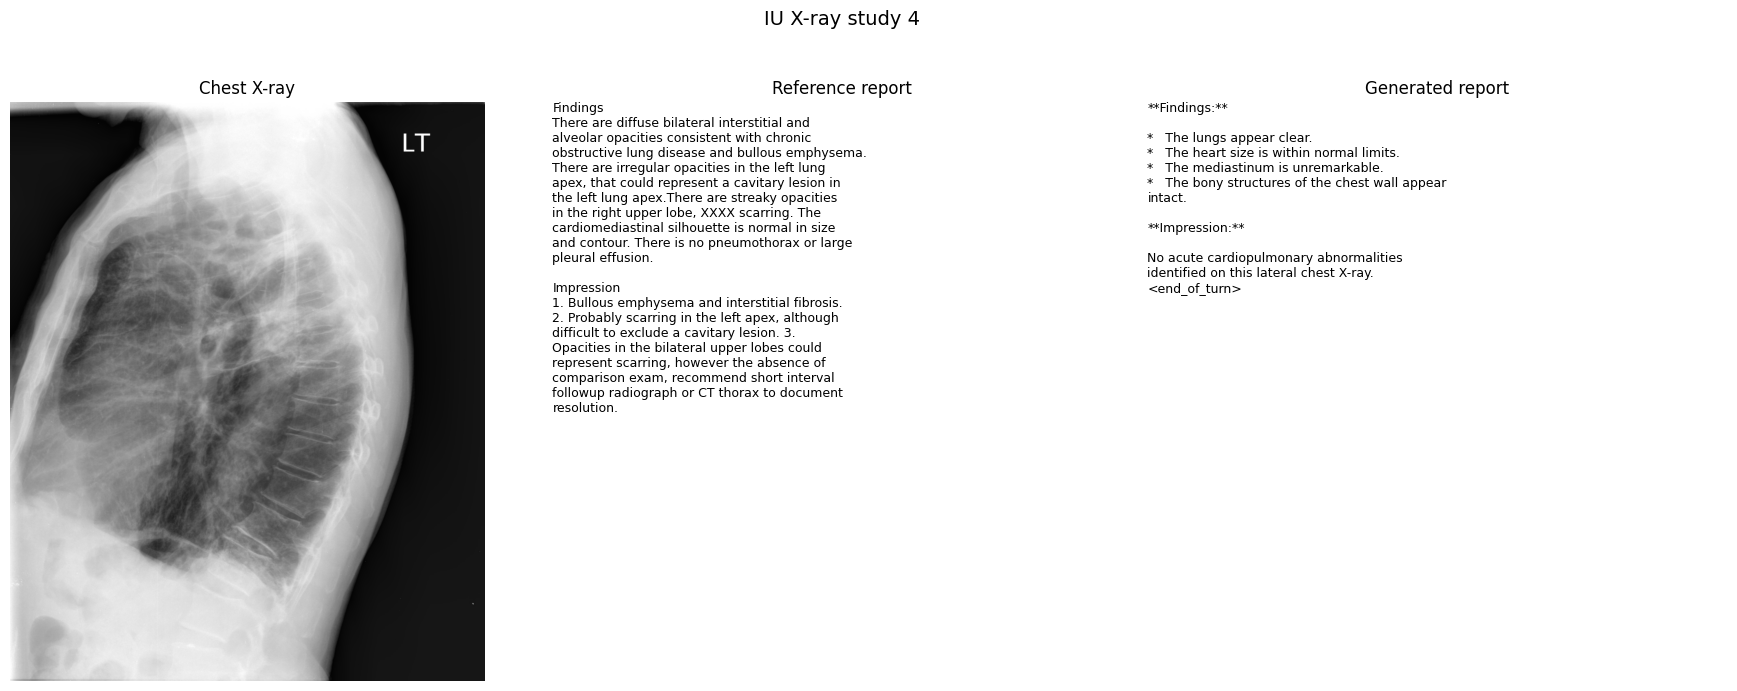

In [11]:
def wrap_report(report, width=48):
    """Wrap report lines without discarding section breaks."""
    return "\n".join(
        textwrap.fill(line, width=width) if line else ""
        for line in report.splitlines()
    )


def add_report_panel(axis, title, report, width=48):
    """Render report text in a Matplotlib axis."""
    axis.text(
        0, 1, wrap_report(report, width),
        va="top", ha="left", fontsize=9, transform=axis.transAxes,
    )
    axis.set_title(title)
    axis.axis("off")


# Place the image, reference, and generated report side by side.
fig, axes = plt.subplots(1, 3, figsize=(18, 7))
axes[0].imshow(image)
axes[0].set_title("Chest X-ray")
axes[0].axis("off")
add_report_panel(axes[1], "Reference report", reference_report)
add_report_panel(axes[2], "Generated report", generated_report)
fig.suptitle(f"IU X-ray study {study['uid']}", fontsize=14)
plt.tight_layout(rect=(0, 0, 1, 0.95))
plt.show()

### Questions for the generated report

1. Which statements appear supported by both the image and reference report?
2. Which  findings did the generated report omit?
3. Did the model introduce new/unsupported findings?
4. How does changing the `PROMPT` affect the output?

## 6. Explore image features

Before generating language, MedGemma's vision encoder converts each image into a sequence of feature vectors, often called **image tokens**. These vectors encode visual information learned during pretraining. We can average, or **mean-pool**, the image tokens to obtain one fixed-length feature vector per X-ray. Such feature vectors can be used independently of the language model—for example, as input to a classifier or for finding visually similar images.

For this demo, we create a two-class proxy problem using a simple report-text heuristic: normal-like reports versus reports that mention cardiomegaly. We compute image features for a balanced sample and visualize them in two dimensions using t-SNE. t-SNE places images with similar high-dimensional features near each other. See van der Maaten and Hinton (2008), [*Visualizing Data using t-SNE*](https://www.jmlr.org/papers/v9/vandermaaten08a.html).


In [ ]:
NORMAL_PHRASES = (
    "no acute cardiopulmonary abnormality",
    "no acute cardiopulmonary disease",
    "no acute cardiopulmonary process",
    "no active cardiopulmonary disease",
    "no acute disease",
    "no acute findings",
    "normal chest",
    "normal exam",
)

CARDIOMEGALY_PHRASES = (
    "cardiomegaly",
    "cardiac enlargement",
    "enlarged cardiac silhouette",
    "enlarged cardiomediastinal silhouette",
    "heart size is enlarged",
    "heart is enlarged",
    "enlargement of the cardiac silhouette",
)
CARDIOMEGALY_NEGATIONS = (
    "no cardiomegaly",
    "without cardiomegaly",
    "no evidence of cardiomegaly",
)


def report_heuristic(row):
    """Assign a proxy label from explicit report wording."""
    report_text = f"{row['findings']} {row['impression']}".casefold()
    mentions_cardiomegaly = any(
        phrase in report_text for phrase in CARDIOMEGALY_PHRASES
    ) and not any(
        phrase in report_text for phrase in CARDIOMEGALY_NEGATIONS
    )
    is_normal = (
        any(phrase in report_text for phrase in NORMAL_PHRASES)
        and not mentions_cardiomegaly
    )
    if mentions_cardiomegaly:
        return "Cardiomegaly (heuristic)"
    if is_normal:
        return "Normal (heuristic)"
    return None


# Retain only studies that match one of the two report-text rules.
feature_candidates = studies.copy()
feature_candidates["feature_label"] = feature_candidates.apply(
    report_heuristic, axis=1
)
feature_candidates = feature_candidates.dropna(subset=["feature_label"])
label_counts = feature_candidates["feature_label"].value_counts()

print(label_counts.rename("available studies").to_string())

In [ ]:
label_names = ["Normal (heuristic)", "Cardiomegaly (heuristic)"]

# Sample within each class, then shuffle their combined order reproducibly.
feature_sample = pd.concat(
    [
        feature_candidates.loc[
            feature_candidates["feature_label"].eq(label)
        ].sample(n=STUDIES_PER_CLASS, random_state=SEED)
        for label in label_names
    ],
    ignore_index=True,
).sample(frac=1, random_state=SEED).reset_index(drop=True)

print(
    f"Feature sample: {len(feature_sample)} studies "
    f"({STUDIES_PER_CLASS} per heuristic class)."
)

### Inspect examples from both groups

Before reducing the features to two dimensions, inspect ten images from each report-derived group. The labels come from processing the report text with a simple heuristic, rather than image review by radiologists, so individual examples may be subtle, noisy, or affected by projection and positioning.

In [ ]:
# Visual inspection helps reveal projection artifacts and label noise.
examples_to_show = 10
fig, axes = plt.subplots(
    2, examples_to_show, figsize=(1.6 * examples_to_show, 4.2)
)

for row_index, label in enumerate(label_names):
    examples = feature_sample.loc[
        feature_sample["feature_label"].eq(label)
    ].head(examples_to_show)
    for column_index, (_, example_study) in enumerate(examples.iterrows()):
        example_image = load_xray(example_study["image_path"])
        axes[row_index, column_index].imshow(example_image)
        axes[row_index, column_index].set_title(
            f"UID {example_study['uid']}", fontsize=7
        )
        axes[row_index, column_index].axis("off")

fig.text(0.01, 0.70, "Normal-like", rotation=90, va="center", fontsize=11)
fig.text(0.01, 0.28, "Cardiomegaly", rotation=90, va="center", fontsize=11)
fig.suptitle("Examples selected by the report heuristic", fontsize=13)
plt.tight_layout(rect=(0.025, 0, 1, 0.92), pad=0.3)
plt.show()

In [ ]:
def extract_image_feature(current_model, current_image):
    """Mean-pool and normalize one image's projected vision tokens."""

    # Resize and normalize one image as a batch of size one, returning PyTorch tensors.
    image_batch = processor.image_processor(
        images=[current_image],
        return_tensors="pt",
    )

    # Move the processed pixel batch to the model's GPU and computation precision.
    pixel_values = image_batch["pixel_values"].to(
        current_model.device, dtype=COMPUTE_DTYPE
    )

    with torch.inference_mode():
        # Run the vision encoder without computing gradients.
        image_tokens = current_model.get_image_features(pixel_values)
        # Average all image-token vectors into one feature vector per image.
        pooled_feature = image_tokens.mean(dim=1)
        # Scale each vector to unit length.
        pooled_feature = torch.nn.functional.normalize(
            pooled_feature, dim=-1
        )

    return pooled_feature[0].float().cpu().numpy()


# Extract one normalized feature vector per sampled study.
image_features = []
for feature_index, (_, feature_study) in enumerate(
    feature_sample.iterrows(), start=1
):
    feature_image = load_xray(feature_study["image_path"])
    image_features.append(extract_image_feature(model, feature_image))
    if feature_index % 25 == 0 or feature_index == len(feature_sample):
        print(f"Extracted {feature_index}/{len(feature_sample)} features.")

image_features = np.stack(image_features)


In [ ]:
# Reduce the high-dimensional features before applying t-SNE.
pca_features = PCA(
    n_components=50, random_state=SEED
).fit_transform(image_features)

# Perplexity 30 is a common starting point for t-SNE.
tsne_coordinates = TSNE(
    n_components=2,
    perplexity=30,
    init="pca",
    learning_rate="auto",
    max_iter=1000,
    random_state=SEED,
).fit_transform(pca_features)

# Color the finished projection with labels that t-SNE never receives.
colors = {
    "Normal (heuristic)": "#2a9d8f",
    "Cardiomegaly (heuristic)": "#e76f51",
}
plt.figure(figsize=(8, 6))
for label in label_names:
    mask = feature_sample["feature_label"].eq(label).to_numpy()
    plt.scatter(
        tsne_coordinates[mask, 0],
        tsne_coordinates[mask, 1],
        s=35, alpha=0.75, color=colors[label],
        label=f"{label} (n={mask.sum()})",
    )
plt.xlabel("t-SNE dimension 1")
plt.ylabel("t-SNE dimension 2")
plt.title("MedGemma features: normal-like vs cardiomegaly")
plt.legend()
plt.grid(alpha=0.2)
plt.show()


### Questions for the feature plot

1. Do nearby points tend to share the same report-derived label?
3. How would the plot change with another pooling rule?
4. What labels and quantitative evaluation would be needed before claiming that the representation captures this pathology?

## 7. Fine-tune with QLoRA

To fine-tune MedGemma, we first prepare a training set of image–report pairs. Each example contains one frontal chest X-ray, the fixed reporting prompt, and its reference report as the target response. The processor converts these elements into one multimodal sequence. During teacher-forced training, the model predicts each report token from the image, prompt, and preceding report tokens. Loss is calculated only for the report because the image and prompt provide context rather than desired output (masking their labels prevents the objective from rewarding reproduction of the instruction and image-placeholder tokens).

A disjoint set of studies is reserved for validation and excluded from optimizer updates. It measures report-prediction loss on examples not used to fit the adapter, although repeated monitoring means it is not an untouched final test set.

During training, the model minimizes next-token prediction loss over the reference reports. **LoRA** is a form of **parameter-efficient fine-tuning (PEFT)**: rather than updating the full language decoder, it learns low-rank updates to selected query and value projection matrices while keeping the original MedGemma parameters frozen. This substantially reduces the number of trainable parameters and the memory required for optimization. See Hu et al. (2021), [*LoRA: Low-Rank Adaptation of Large Language Models*](https://arxiv.org/abs/2106.09685).

MedGemma's frozen weights are kept in 4-bit NF4 form while the adapters are trained with FP32 computation. This combination is **QLoRA**; see Dettmers et al. (2023), [*QLoRA: Efficient Finetuning of Quantized LLMs*](https://arxiv.org/abs/2305.14314). FP32 avoids unstable FP16 outputs and behaves consistently across the supported GPUs, but makes this demonstration slower.

> **Runtime note:** The default setup trains on 100 studies and evaluates performance on 20 validation studies at five points during training. The Settings section discusses configuration values for a larger experiment.

We use the term **training block** for a fixed number of consecutive training examples between progress reports and validation runs. A block is not an epoch: each study is used once, and completing all blocks corresponds to one pass through the selected training subset.


In [ ]:
training_blocks = TRAINING_STUDIES // STUDIES_PER_BLOCK

# Shuffle once, then take non-overlapping training and validation slices.
split_studies = studies.sample(
    n=TRAINING_STUDIES + VALIDATION_STUDIES, random_state=SEED
).reset_index(drop=True)
finetune_studies = split_studies.iloc[:TRAINING_STUDIES]
validation_studies = split_studies.iloc[TRAINING_STUDIES:]

training_study = finetune_studies.iloc[0]
validation_study = validation_studies.iloc[0]
training_image = load_xray(training_study["image_path"])
validation_image = load_xray(validation_study["image_path"])
training_reference = format_reference(training_study)
validation_reference = format_reference(validation_study)

# Save pretrained outputs before adding adapters.
training_before = generate_report(
    model, training_image, PROMPT, MAX_NEW_TOKENS
)
validation_before = generate_report(
    model, validation_image, PROMPT, MAX_NEW_TOKENS
)
print(f"Training studies: {len(finetune_studies)}")
print(f"Validation studies: {len(validation_studies)}")
print(f"Training blocks: {training_blocks}")

### Add trainable adapters

The adapters are added only to the language decoder's query and value projections. The vision encoder therefore remains frozen. Rank `r=8` controls the small inner dimension of each adapter. Gradient checkpointing saves memory by recomputing some activations during backpropagation.


In [ ]:
from peft import (
    LoraConfig,
    get_peft_model,
    prepare_model_for_kbit_training,
)

torch.manual_seed(SEED)

# Freeze and prepare the 4-bit base model for LoRA training. Gradient
# checkpointing reduces memory use by recomputing activations during backward.
# Non-reentrant checkpointing needs to be set when only the LoRA adapters, rather
# than the model inputs or frozen base weights, require gradients.
model = prepare_model_for_kbit_training(
    model,
    use_gradient_checkpointing=True,
    gradient_checkpointing_kwargs={"use_reentrant": False},
)

# Select only the query and value projections in the language decoder.
# Full module paths exclude similarly named layers in the vision encoder.
text_lora_targets = [
    name
    for name, _ in model.named_modules()
    if "language_model" in name
    and name.endswith(("q_proj", "v_proj"))
]

# Fail early if the model's module structure differs from what we expect.
if not text_lora_targets:
    raise RuntimeError("Could not find language-decoder query/value projections.")

# Configure low-rank adapters for the selected language-decoder projections.
lora_config = LoraConfig(
    r=8,                           # Rank of each low-dimensional update.
    lora_alpha=8,                  # Update scaling; alpha/r gives a scale of 1.
    lora_dropout=0.05,             # Apply dropout on the adapter input.
    target_modules=text_lora_targets,
    bias="none",                   # Keep the original bias parameters frozen.
)

# Insert the LoRA adapters and return a PEFT-wrapped model.
model = get_peft_model(model, lora_config)

# Disable generation-oriented key/value caching during checkpointed training.
model.config.text_config.use_cache = False

# Enable training behavior, including LoRA dropout.
model.train()

# Report how many parameters are trainable after adding the adapters.
model.print_trainable_parameters()


### Build assistant-only training labels

For each training example, the processor creates two model inputs:

- `input_ids`: the sequence of integer token identifiers representing the system message, image placeholders, user prompt, and assistant report. Each identifier refers to a token in the model's vocabulary.
- `pixel_values`: the processed image data associated with those placeholders.

Both are passed to the model in the same training step. The model learns to predict each report token using the image, the prompt, and the correct preceding report tokens. Providing the correct (and not the predicted) preceding tokens during training is called **teacher forcing**.

The `labels` tensor serves a different purpose: it specifies the target token at each position and therefore which positions contribute to cross-entropy loss. We copy `input_ids` into `labels`, then replace the labels for the image and prompt portion with `-100`, PyTorch's ignore value. This masks the **loss**, not the **input**. The context tokens still influence the model through attention, but no error is assigned for predicting the fixed system message, prompt, or image placeholders. The resulting objective trains the conditional behavior we want—predicting the assistant report given the image and prompt—rather than spending much of the learning signal on reproducing the input template.

With pan-and-scan disabled, every example contributes the same fixed number of image tokens. We therefore determine the prompt boundary once and verify that it is an exact prefix of one complete training conversation.

The training sequence is capped by `MAX_TRAINING_TOKENS` to keep memory predictable.


In [ ]:
# Measure the prompt once so its tokens can be excluded from the loss.
prompt_batch = encode_messages(
    make_messages(training_image, PROMPT),
    add_generation_prompt=True,
)
prompt_token_count = prompt_batch["input_ids"].shape[1]


def make_training_batch(row, current_model):
    """Encode one study and mask every token before the target report."""
    row_image = load_xray(row["image_path"])
    batch = encode_messages(
        make_messages(
            row_image,
            PROMPT,
            assistant_text=format_reference(row),
        ),
        add_generation_prompt=False,
        truncation=True,
        max_length=MAX_TRAINING_TOKENS,
    )
    if prompt_token_count >= batch["input_ids"].shape[1]:
        raise RuntimeError("The reference report produced no target tokens.")

    labels = batch["input_ids"].clone()
    labels[:, :prompt_token_count] = -100
    batch["labels"] = labels
    return move_batch_to_gpu(batch, current_model.device)


# Verify the masking boundary once, rather than trusting a token count blindly.
example_batch = make_training_batch(finetune_studies.iloc[0], model)
if not torch.equal(
    example_batch["input_ids"][0, :prompt_token_count].cpu(),
    prompt_batch["input_ids"][0],
):
    raise RuntimeError("The chat template is not prefix-preserving.")
target_token_count = int(example_batch["labels"].ne(-100).sum())
print(f"First reference target: {target_token_count} tokens.")
del prompt_batch, example_batch


### Train and validate the adapters

The next cell performs one pass through the selected training studies and periodically measures validation loss. The optimizer receives only parameters with `requires_grad=True`, so it updates the LoRA adapters while the quantized MedGemma weights remain frozen. To fit within GPU memory, training uses a batch size of one: for each study, the loop clears old gradients, computes the assistant-only report loss, backpropagates, clips the gradients, and performs one optimizer step. Training loss is then averaged over each block for reporting.

At the configured intervals, the model switches to evaluation mode and computes the same report-prediction loss across the validation studies without gradients or parameter updates. It then returns to training mode for the next block. Comparing the two loss curves helps reveal optimization progress and possible overfitting, but lower loss alone does not establish that generated reports are clinically correct.


In [ ]:
trainable_parameters = [
    parameter for parameter in model.parameters() if parameter.requires_grad
]
optimizer = torch.optim.AdamW(
    trainable_parameters, lr=FINETUNE_LEARNING_RATE
)
training_losses = []
validation_blocks = []
validation_losses = []

# Each block reports the mean of several batch-size-one optimizer steps.
for block_index in range(training_blocks):
    start = block_index * STUDIES_PER_BLOCK
    stop = start + STUDIES_PER_BLOCK
    block_studies = finetune_studies.iloc[start:stop]
    block_loss = 0.0

    # Batch size is one; each study produces one optimizer update.
    for _, training_study in block_studies.iterrows():
        optimizer.zero_grad(set_to_none=True)
        batch = make_training_batch(training_study, model)
        loss = model(**batch).loss

        loss.backward()
        torch.nn.utils.clip_grad_norm_(trainable_parameters, max_norm=1.0)
        optimizer.step()
        block_loss += loss.detach().item()
        # Drop references promptly to stay within the 11 GB GPU budget.
        del batch, loss

    mean_training_loss = block_loss / len(block_studies)
    training_losses.append(mean_training_loss)
    completed_block = block_index + 1
    should_validate = (
        completed_block % VALIDATE_EVERY_N_BLOCKS == 0
        or completed_block == training_blocks
    )

    if should_validate:
        model.eval()
        validation_total = 0.0
        with torch.inference_mode():
            for _, validation_row in validation_studies.iterrows():
                validation_batch = make_training_batch(validation_row, model)
                validation_loss = model(**validation_batch).loss
                validation_total += validation_loss.item()
                # Validation also runs close to the GPU memory limit.
                del validation_batch, validation_loss

        mean_validation_loss = validation_total / len(validation_studies)
        validation_blocks.append(completed_block)
        validation_losses.append(mean_validation_loss)
        model.train()
        print(
            f"Block {completed_block:03d}/{training_blocks}: "
            f"train = {mean_training_loss:.4f}, "
            f"validation = {mean_validation_loss:.4f}"
        )
    else:
        print(
            f"Block {completed_block:03d}/{training_blocks}: "
            f"train = {mean_training_loss:.4f}"
        )

In [ ]:
# Training loss is averaged per block; validation loss uses the full split.
plt.figure(figsize=(7, 4))
blocks = range(1, training_blocks + 1)
plt.plot(
    blocks, training_losses,
    label=f"Training ({STUDIES_PER_BLOCK} studies per block)",
)
plt.plot(
    validation_blocks, validation_losses, marker="o",
    label=f"Validation ({VALIDATION_STUDIES} studies)",
)
plt.xlabel("Training block")
plt.ylabel("Report-prediction loss")
plt.title("LoRA training and validation loss")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### Compare reports before and after adaptation

The first row was used for training, so a change may reflect memorization. The second row is from the repeatedly monitored validation set. It was excluded from optimizer updates, but it is not an untouched test example. Two examples are only useful for qualitative inspection, but cannot establish effectiveness. For that a proper quantiative evaluation is neede.


In [ ]:
# Non-reentrant checkpointing installs no input-gradient hook to remove.
# Disable checkpointing itself, restore caching, and switch to evaluation.
model.gradient_checkpointing_disable()
model.config.text_config.use_cache = True
model.eval()

# Generate adapted outputs for one training and one validation example.
training_after = generate_report(
    model, training_image, PROMPT, MAX_NEW_TOKENS
)
validation_after = generate_report(
    model, validation_image, PROMPT, MAX_NEW_TOKENS
)
comparison_rows = [
    (
        "Training example", training_image, training_reference,
        training_before, training_after,
    ),
    (
        "Validation example", validation_image, validation_reference,
        validation_before, validation_after,
    ),
]

fig, axes = plt.subplots(2, 4, figsize=(24, 13))
for row_index, (label, xray, reference, before, after) in enumerate(
    comparison_rows
):
    axes[row_index, 0].imshow(xray)
    axes[row_index, 0].set_title(f"{label}\nChest X-ray")
    axes[row_index, 0].axis("off")
    for column, (title, report) in enumerate(
        [
            ("Reference report", reference),
            ("Pretrained report (4-bit)", before),
            ("QLoRA-adapted report", after),
        ],
        start=1,
    ):
        add_report_panel(axes[row_index, column], title, report, width=42)

fig.suptitle("Before and after MedGemma QLoRA adaptation", fontsize=15)
plt.tight_layout(rect=(0, 0, 1, 0.96))
plt.show()


### Interpret the comparison

1. Did adaptation improve clinical agreement, or only formatting and fluency?